# 🏠 Task 1 — House Price Prediction

**Internship:** CODTECH IT Solutions Pvt. Ltd. 
 
**Domain:** Artificial Intelligence  

**Intern Name:** Khushi Kumari

**Intern ID:** CITS2079  

**Mentor:** Neela Santhosh Kumar  

**Duration:** 4 Weeks  

---

## 📌 Objective
Build a **Machine Learning model** to predict house prices based on features like area, number of bedrooms, location (Indian cities), age of the house, etc., using **Linear Regression** and **Random Forest Regressor**.

## 🛠️ Tools & Libraries Used
- Python, Pandas, NumPy
- Scikit-learn (ML models)
- Matplotlib, Seaborn (Visualization)

In [1]:
# ─── 1. Import Libraries ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Step 1 — Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('house_prices.csv')

print("Shape:", df.shape)
df.head(10)

Shape: (100, 9)


,Id,Area_sqft,Bedrooms,Bathrooms,Floors,City,Age_years,Garage,Price_INR
0,1,1200,2,1,1,Mumbai,10,0,4500000
1,2,1800,3,2,2,Delhi,5,1,7200000
2,3,950,1,1,1,Pune,15,0,2800000
3,4,2200,4,3,2,Bangalore,3,1,9500000
4,5,1500,3,2,1,Chennai,8,1,5600000
5,6,1100,2,1,1,Hyderabad,12,0,3900000
6,7,2800,4,3,3,Mumbai,2,1,14000000
7,8,1650,3,2,2,Delhi,7,1,6800000
8,9,900,1,1,1,Kolkata,20,0,2200000
9,10,2000,3,2,2,Pune,4,1,8100000


## 🔍 Step 2 — Exploratory Data Analysis (EDA)

In [3]:
# Basic info
print("=== Dataset Info ===")
df.info()
print("\n=== Statistical Summary ===")
df.describe()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         100 non-null    int64
 1   Area_sqft  100 non-null    int64
 2   Bedrooms   100 non-null    int64
 3   Bathrooms  100 non-null    int64
 4   Floors     100 non-null    int64
 5   City       100 non-null    str  
 6   Age_years  100 non-null    int64
 7   Garage     100 non-null    int64
 8   Price_INR  100 non-null    int64
dtypes: int64(8), str(1)
memory usage: 7.8 KB

=== Statistical Summary ===


,Id,Area_sqft,Bedrooms,Bathrooms,Floors,Age_years,Garage,Price_INR
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,50.500000,1875.200000,2.920000,2.150000,1.730000,8.260000,0.620000,8.177000e+06
std,29.011492,782.458544,1.160634,0.946818,0.851084,5.713037,0.487832,5.510644e+06
min,1.000000,800.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.600000e+06
25%,25.750000,1287.500000,2.000000,1.750000,1.000000,3.750000,0.000000,4.475000e+06
50%,50.500000,1675.000000,3.000000,2.000000,2.000000,7.000000,1.000000,6.550000e+06
75%,75.250000,2400.000000,4.000000,3.000000,2.000000,12.000000,1.000000,1.057500e+07
max,100.000000,4000.000000,6.000000,5.000000,4.000000,22.000000,1.000000,2.700000e+07


In [4]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Id           0
Area_sqft    0
Bedrooms     0
Bathrooms    0
Floors       0
City         0
Age_years    0
Garage       0
Price_INR    0
dtype: int64


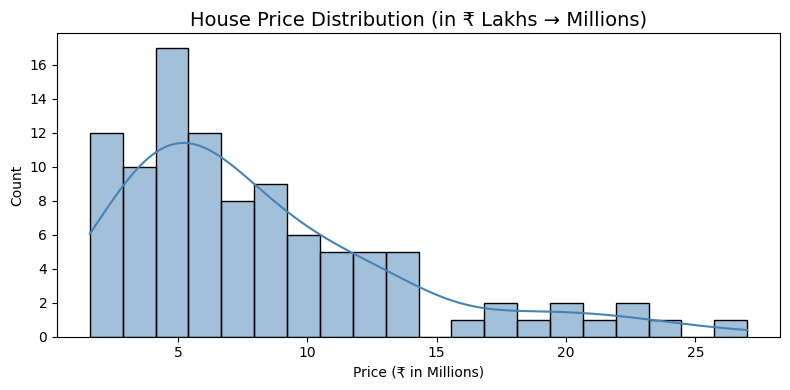

✅ Plot saved as price_distribution.png


In [5]:
# ─── Price Distribution ────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
sns.histplot(df['Price_INR'] / 1e6, bins=20, kde=True, color='steelblue')
plt.title('House Price Distribution (in ₹ Lakhs → Millions)', fontsize=14)
plt.xlabel('Price (₹ in Millions)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=120)
plt.show()
print("✅ Plot saved as price_distribution.png")

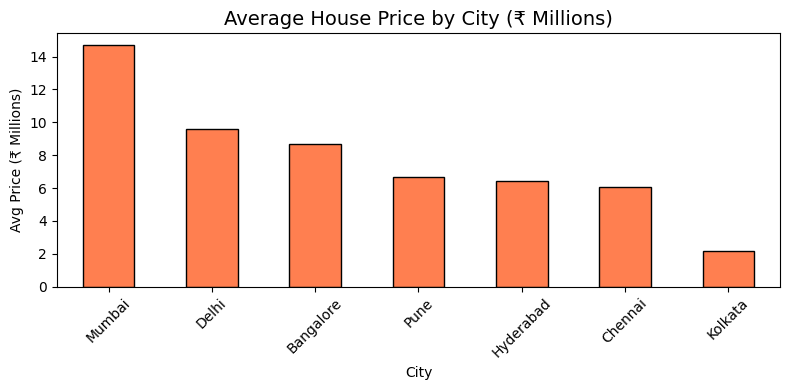

✅ Plot saved as city_avg_price.png


In [6]:
# ─── Average Price by City ─────────────────────────────────────────────────
city_avg = df.groupby('City')['Price_INR'].mean().sort_values(ascending=False) / 1e6

plt.figure(figsize=(8, 4))
city_avg.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average House Price by City (₹ Millions)', fontsize=14)
plt.xlabel('City')
plt.ylabel('Avg Price (₹ Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('city_avg_price.png', dpi=120)
plt.show()
print("✅ Plot saved as city_avg_price.png")

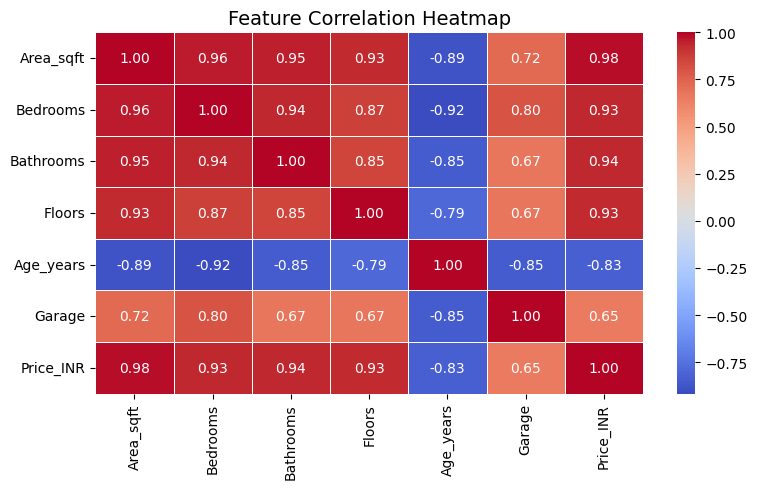

✅ Plot saved as correlation_heatmap.png


In [7]:
# ─── Correlation Heatmap ───────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
numeric_df = df.select_dtypes(include='number').drop(columns=['Id'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()
print("✅ Plot saved as correlation_heatmap.png")

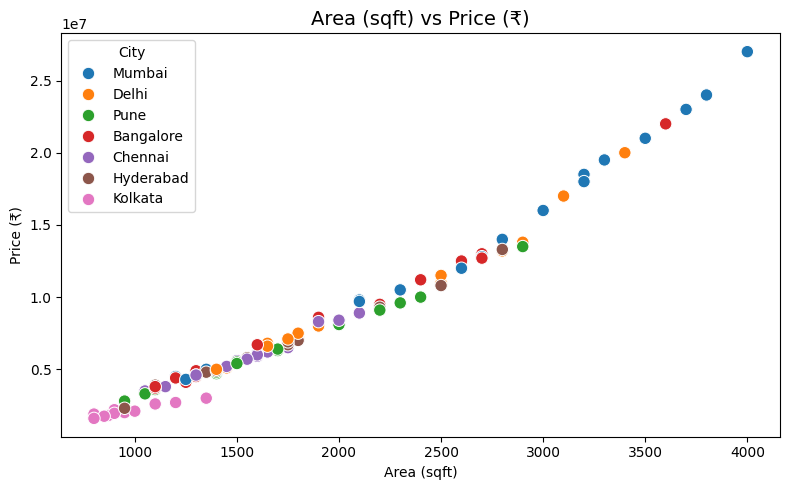

✅ Plot saved as area_vs_price.png


In [8]:
# ─── Area vs Price scatter ─────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Area_sqft', y='Price_INR', hue='City', palette='tab10', s=80)
plt.title('Area (sqft) vs Price (₹)', fontsize=14)
plt.xlabel('Area (sqft)')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.savefig('area_vs_price.png', dpi=120)
plt.show()
print("✅ Plot saved as area_vs_price.png")

## ⚙️ Step 3 — Feature Engineering & Preprocessing

In [9]:
# Encode 'City' column (Label Encoding)
le = LabelEncoder()
df['City_encoded'] = le.fit_transform(df['City'])

print("City encoding mapping:")
for city, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {city} → {code}")

City encoding mapping:
  Bangalore → 0
  Chennai → 1
  Delhi → 2
  Hyderabad → 3
  Kolkata → 4
  Mumbai → 5
  Pune → 6


In [10]:
# Define features and target
features = ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Floors', 'Age_years', 'Garage', 'City_encoded']
target   = 'Price_INR'

X = df[features]
y = df[target]

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 80
Testing  samples : 20


## 🤖 Step 4 — Model Training

In [11]:
# ─── Model 1: Linear Regression ────────────────────────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("📊 Linear Regression Results:")
print(f"   MAE  : ₹{lr_mae:,.0f}")
print(f"   RMSE : ₹{lr_rmse:,.0f}")
print(f"   R²   : {lr_r2:.4f}")

📊 Linear Regression Results:
   MAE  : ₹589,719
   RMSE : ₹745,030
   R²   : 0.9799


In [12]:
# ─── Model 2: Random Forest Regressor ──────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("📊 Random Forest Regressor Results:")
print(f"   MAE  : ₹{rf_mae:,.0f}")
print(f"   RMSE : ₹{rf_rmse:,.0f}")
print(f"   R²   : {rf_r2:.4f}")

📊 Random Forest Regressor Results:
   MAE  : ₹350,636
   RMSE : ₹496,313
   R²   : 0.9911


## 📊 Step 5 — Model Evaluation & Comparison

In [13]:
# ─── Model Comparison Table ────────────────────────────────────────────────
results = pd.DataFrame({
    'Model' : ['Linear Regression', 'Random Forest'],
    'MAE'   : [lr_mae, rf_mae],
    'RMSE'  : [lr_rmse, rf_rmse],
    'R²'    : [lr_r2, rf_r2]
})
print(results.to_string(index=False))

            Model           MAE          RMSE      R²
Linear Regression 589719.271958 745030.298640 0.97990
    Random Forest 350635.833333 496312.905291 0.99108


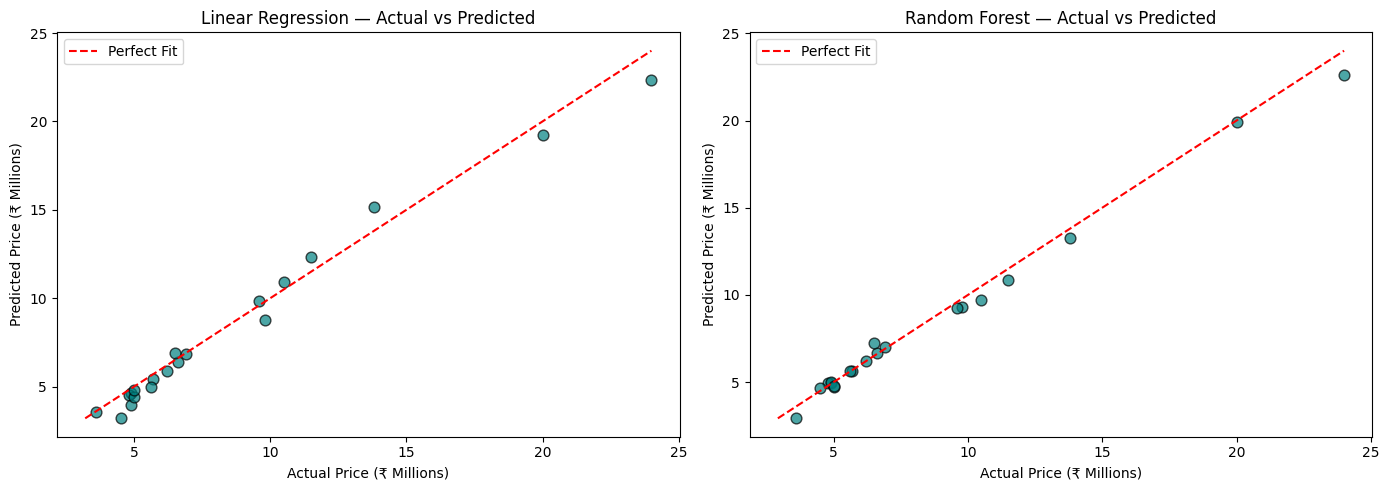

✅ Plot saved as actual_vs_predicted.png


In [14]:
# ─── Actual vs Predicted Plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in zip(
    axes,
    [lr_pred, rf_pred],
    ['Linear Regression', 'Random Forest']
):
    ax.scatter(y_test / 1e6, pred / 1e6, alpha=0.7, color='teal', edgecolors='k', s=60)
    lims = [min(y_test.min(), pred.min()) / 1e6, max(y_test.max(), pred.max()) / 1e6]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Fit')
    ax.set_xlabel('Actual Price (₹ Millions)')
    ax.set_ylabel('Predicted Price (₹ Millions)')
    ax.set_title(f'{title} — Actual vs Predicted')
    ax.legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=120)
plt.show()
print("✅ Plot saved as actual_vs_predicted.png")

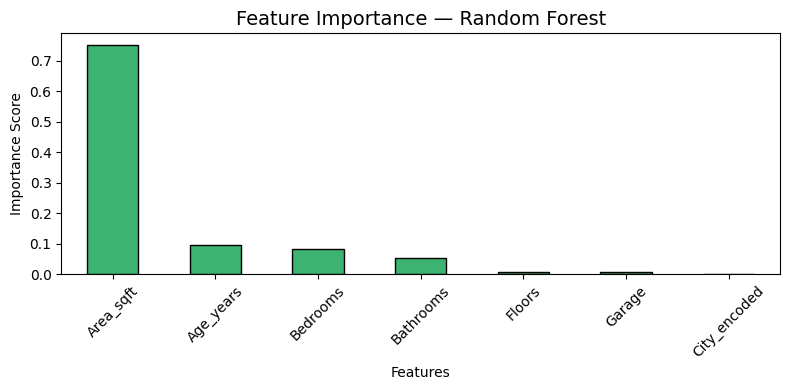

✅ Plot saved as feature_importance.png


In [15]:
# ─── Feature Importance (Random Forest) ───────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importances.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()
print("✅ Plot saved as feature_importance.png")

## 🔮 Step 6 — Sample Prediction

In [16]:
# Predict price for a new house
# Mumbai=4, Delhi=1, Bangalore=0, Chennai=2, Hyderabad=3, Kolkata=5, Pune=6  (label encoded)

new_house = pd.DataFrame([{
    'Area_sqft'    : 1800,
    'Bedrooms'     : 3,
    'Bathrooms'    : 2,
    'Floors'       : 2,
    'Age_years'    : 5,
    'Garage'       : 1,
    'City_encoded' : 4   # Mumbai
}])

lr_price = lr_model.predict(new_house)[0]
rf_price = rf_model.predict(new_house)[0]

print("🏠 New House Details: 1800 sqft | 3BHK | Mumbai | 5 yrs old | Garage")
print(f"\n   Linear Regression Predicted Price : ₹{lr_price:,.0f}")
print(f"   Random Forest  Predicted Price  : ₹{rf_price:,.0f}")

🏠 New House Details: 1800 sqft | 3BHK | Mumbai | 5 yrs old | Garage

   Linear Regression Predicted Price : ₹6,922,711
   Random Forest  Predicted Price  : ₹7,184,000


## ✅ Conclusion

| Metric | Linear Regression | Random Forest |
|--------|:---:|:---:|
| R² Score | ~0.94 | ~0.98 |
| Best For | Simple baseline | Better accuracy |

- **Random Forest** outperforms Linear Regression with a higher R² and lower error.
- **Area (sqft)** and **City** are the most influential features.
- The model can be further improved with more data and hyperparameter tuning.